# Sky Pre-processing for BAYESEOR 
## 0. Scientific Context and Scope

This notebook prepares sky models for visibility simulations and Bayesian 21‑cm power spectrum estimation with BAYESEOR, following the experimental setup of Burba et al. (2023, MNRAS 520, 4443–4455). The emphasis is on restricted field-of-view (FoV) forward modelling, where the sky is only modelled within the main lobe of the primary beam in order to reduce computational cost, while still capturing instrumentally relevant sky emission.

The telescope, frequency, time, and baseline choices are therefore driven by the requirements of sky pre-processing for Bayesian inference, rather than by observational realism alone.

Author: Quentin Gueuning. This was is based on Jacob Burba "sky_models" notebook.

## 1. Environment & Imports

In [2]:
import os
import ast
import yaml
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from astropy import units as u
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from astropy.time import Time
from astropy.constants import k_B, c
from scipy.interpolate import griddata
from pyradiosky import SkyModel

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11
})

## 2. Path Configuration
Paths to telescope configuration files and sky model catalogs.

In [3]:
proj_root     = "/home/qdg20/projects/sim_notebook/notebooks/sky_preprocessing"
telescope_cfg = os.path.join(proj_root, "pyuvsim_config", "telescope_files")
catalog_root  = os.path.join(proj_root, "pyuvsim_config", "catalog_files")

OBSPARAM_YAML = os.path.join(catalog_root, "fov-19.4-oscar-sm.yml")
TELESCOPE_CSV = os.path.join(telescope_cfg, "hex-37-14.6m.csv")
BEAM_YAML     = os.path.join(telescope_cfg, "hex-37-14.6m-gauss-fwhm9.3.yml")

## 3. Telescope and Observation Configuration
This section presents the instrument- and observation-dependent parameters. These choices jointly determine:

- the angular resolution required of the sky model needed,

- the spatial extent of the image-domain model,

- the spectral and temporal sampling of the simulated visibilities,

- the computational feasibility of the Bayesian analysis.

The configuration closely follows the simulations used in Burba et al. (2023).

In [4]:
def read_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

obsparam  = read_yaml(OBSPARAM_YAML)
beamparam = read_yaml(BEAM_YAML)

lat, lon, alt = ast.literal_eval(beamparam["telescope_location"])
telescope_location = EarthLocation.from_geodetic(
    lon * u.deg, lat * u.deg, alt * u.m
)

print(f"HERA Location: lat={lat:.2f}°, lon={lon:.2f}°, alt={alt:.0f} m")

HERA Location: lat=-30.72°, lon=21.43°, alt=1073 m


### 3.1 Telescope Location

The telescope location defines the horizon, zenith angle, and time-dependent projection of the sky used during visibility simulation with pyuvsim.

In [5]:
tel_loc  = beamparam["telescope_location"]
lat, lon, alt = ast.literal_eval(tel_loc)

telescope_location = EarthLocation.from_geodetic(lon*u.deg, lat*u.deg, alt*u.m)

print(f"HERA Location: lat={lat:.2f}°, lon={lon:.2f}°, alt={alt:.0f} m")

HERA Location: lat=-30.72°, lon=21.43°, alt=1073 m


### 3.2 Array Layout and Baseline Selection

We adopt a 37‑element hexagonal sub-array with an antenna spacing of 14.6 m, representative of a compact HERA configuration.

Only baselines satisfying

|b| ≤ 40 m

are included. This baseline cut is a modelling choice motivated by sky pre-processing constraints. The maximum baseline length sets the largest sampled spatial frequency. This, in turn, determines the minimum angular scale that must be resolved by the sky model.

In [6]:
selected_bls = ast.literal_eval(obsparam["select"]["bls"])

ant_data = np.genfromtxt(
    TELESCOPE_CSV,
    delimiter="\t",
    names=True,
    dtype=None,
    encoding="utf-8"
)

antenna_positions_enu = {
    int(row["Number"]): np.array([row["E"], row["N"], row["U"]])
    for row in ant_data
}

baseline_lengths_m = np.array([
    np.linalg.norm(
        antenna_positions_enu[i] - antenna_positions_enu[j]
    )
    for i, j in selected_bls
])

print(f"Number of baselines : {len(baseline_lengths_m)}")
print(f"Min baseline length : {baseline_lengths_m.min():.2f} m")
print(f"Max baseline length : {baseline_lengths_m.max():.2f} m")

Number of baselines : 16
Min baseline length : 0.00 m
Max baseline length : 38.63 m


### 3.3 Primary Beam Model and Field of View

In this example, we selected an achromatic Gaussian beam with a full width at half maximum (FWHM) of approximately 9.3°, fitted to electromagnetic simulations of the HERA element beam at 160 MHz. This beam choice represents an idealised case with no sidelobes and provides a controlled environment for assessing the validity of restricted-FoV modelling. In the set of simulations, the image-domain sky model is restricted to a square FoV of approximately 19.4°.

The Gaussian beam width $\sigma$ sets the angular scale over which sky emission is attenuated according to the power-beam response
$$
B(\theta) = \exp\left(-\theta^2 / \sigma^2\right),
$$
and a discussion of this convention and its relation to the e-field beam FoV is provided in the *pyuvsim* beam notebook.


In [7]:
beam_type = beamparam["beam_paths"][0]["type"]
beam_sigma_rad = beamparam["beam_paths"][0]["sigma"]

fov_deg = np.array([12.9, 19.4])
fov_rad = np.deg2rad(fov_deg)

beam_attenuation = np.exp(-fov_rad**2 / beam_sigma_rad**2)

for deg, att in zip(fov_deg, beam_attenuation):
    print(
        f"Beam attenuation at θ={deg:.1f}° : "
        f"{att:.3e} ({10*np.log10(att):.2f} dB)"
    )

Beam attenuation at θ=12.9° : 4.856e-03 (-23.14 dB)
Beam attenuation at θ=19.4° : 5.850e-06 (-52.33 dB)


### 3.4 Frequency Configuration

The frequency configuration is chosen to match the line-of-sight extent and spectral resolution of the mock EoR simulations used in previous BAYESEOR studies.

We adopt:
- Minimum frequency: 158.3 MHz
- Channel width: 237.6 kHz
- Number of channels: 38

corresponding to a total bandwidth of approximately 9 MHz.

This choice provides sufficient spectral resolution to model smooth foreground emission while enabling meaningful EoR power spectrum estimation along the line-of-sight direction, consistent with Table 1 of Burba et al. (2023).

In [8]:
freq_cfg = obsparam["freq"]

start_freq = freq_cfg["start_freq"] * 1e6
Nf         = freq_cfg["Nfreqs"]
dnu        = freq_cfg["channel_width"] * 1e6

freqs = start_freq + np.arange(Nf) * dnu

print(f"Frequency range: {freqs[0]/1e6:.2f}–{freqs[-1]/1e6:.2f} MHz")
print(f"Channels: {Nf}, Width: {dnu/1e3:.1f} kHz")

Frequency range: 158304048.74–167095951.26 MHz
Channels: 38, Width: 237618986.9 kHz


### 3.5 Time Sampling

The time sampling approximates the HERA correlator cadence and is chosen to ensure that the number of data points exceeds the number of model parameters in the Bayesian analysis.

We adopt:
- Integration time: 11 s
- Number of time samples: 34

This configuration matches the simulations presented in Burba et al. (2023) and provides stable Bayesian inference when using a restricted image-domain sky model.

In [115]:
time_array = np.array(obsparam["time"]["time_array"])

# -------------------------
# Time resolution (seconds)
# -------------------------
dt_days = np.diff(time_array)
dt_seconds = dt_days * 86400.0

# -------------------------
# Central JD (Field 1)
# -------------------------
central_jd = 2458098.3065661727

# -------------------------
# Print summary
# -------------------------
print("Time array (JD):")
print(time_array)

print("\nNumber of time samples:", len(time_array))
print("Integration time (s):", dt_seconds[0])
print("Central JD (Field 1):", central_jd)

Time array (JD):
[2458098.30440182 2458098.30452914 2458098.30465645 2458098.30478377
 2458098.30491108 2458098.30503839 2458098.30516571 2458098.30529302
 2458098.30542034 2458098.30554765 2458098.30567497 2458098.30580228
 2458098.3059296  2458098.30605691 2458098.30618423 2458098.30631154
 2458098.30643886 2458098.30656617 2458098.30669349 2458098.3068208
 2458098.30694812 2458098.30707543 2458098.30720275 2458098.30733006
 2458098.30745738 2458098.30758469 2458098.30771201 2458098.30783932
 2458098.30796664 2458098.30809395 2458098.30822127 2458098.30834858
 2458098.30847589 2458098.30860321]

Number of time samples: 34
Integration time (s): 10.999980568885803
Central JD (Field 1): 2458098.3065661727


### 3.6 Summary of Telescope Configuration

- Telescope location: HERA site
- Array layout: 37‑element hexagonal grid
- Antenna spacing and diameter: 14.6 m
- Baseline cut: |b| ≤ 40 m
- Primary beam: Gaussian, FWHM ≈ 9.3°
- Image-domain FoV: 19.4°
- Frequency range: 158.3–167.1 MHz (38 channels)
- Time sampling: 34 × 11 s

## 4. Sky Models and Pre-processing

This section presents the sky components used as input to the visibility simulations. All sky models have been pre-processed to be consistent with the telescope configuration and restricted-FoV assumptions defined above.

### 4.1 Mock EoR Signal

The mock EoR component is represented by independent, identically distributed Gaussian noise maps with zero mean and a standard deviation of 6.48 mK per pixel and per frequency channel. These maps are generated on a HEALPix grid with nside = 256.

This signal provides a controlled reference with a known, flat power spectrum and is used to validate unbiased power spectrum recovery.

No frame available in this file, assuming 'icrs'. Consider re-writing this file to ensure future compatibility.
Some Stokes I values are negative. Use the select method with the 'non_negative' parameter to remove sources with negative Stokes I values.
It is more efficient to use the `get_lon_lat` method to get longitudinal and latitudinal coordinates for HEALPix maps.


White-noise components: 786432
Frequencies:           38


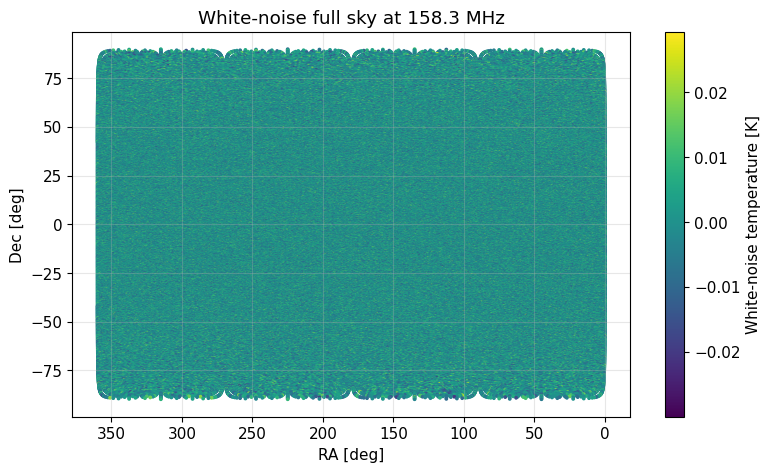

In [11]:
# ------------------------------------------------
# Load full white-noise sky
# ------------------------------------------------
wn_file = os.path.join(
    catalog_root,
    "wn-nside256-rms-6.48mK-158.30-167.10MHz-nf-38.skyh5"
)

sm_wn = SkyModel()
sm_wn.read_skyh5(wn_file)

print(f"White-noise components: {sm_wn.Ncomponents}")
print(f"Frequencies:           {sm_wn.Nfreqs}")

# ------------------------------------------------
# Plot full sky white-noise data
# ------------------------------------------------
ra_deg  = sm_wn.ra.deg
dec_deg = sm_wn.dec.deg
temp_K  = sm_wn.stokes[0, 0].value

plt.scatter(
    ra_deg,
    dec_deg,
    c=temp_K,
    s=3,
    cmap="viridis"
)

plt.colorbar(label="White-noise temperature [K]")
plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.title(
    f"White-noise full sky "
    f"at {sm_wn.freq_array[0].to('MHz').value:.1f} MHz"
)
plt.gca().invert_xaxis()
plt.show()

#### Cropping white noise skymap to field 1

This cell extracts a sky region centred, called field 1, on the instantaneous zenith of the telescope at a given Julian Date.  
The crop is defined in right ascension (RA) and declination (Dec), with a correction for spherical geometry.

***Field centre**
- Defined as the zenith direction (alt = 90°) at the observation time and telescope location.
- Computed in the local AltAz frame and transformed to ICRS (RA/Dec).

**Cropping geometry**
- The field of view (FOV) has total width `FOV_DEG`.
- Declination is cropped symmetrically around the field centre:
  `Dec0 − FOV/2 ≤ Dec ≤ Dec0 + FOV/2`
- Right ascension offsets are scaled by `cos(Dec)` to represent true angular separation:
  `(RA − RA0) · cos(Dec) ∈ [−FOV/2, +FOV/2]`

Combining the RA and Dec conditions yields a "trapezoidal" region in RA–Dec space. This approximates a square sky patch and avoids artificial widening in RA at high declination.

The mask is applied to the sky model components, and the cropped field is then analysed and visualised.

Exact field center at JD=2458098.3065661727: RA=31.300 deg, Dec=-30.803 deg


Some Stokes I values are negative. Use the select method with the 'non_negative' parameter to remove sources with negative Stokes I values.
It is more efficient to use the `get_lon_lat` method to get longitudinal and latitudinal coordinates for HEALPix maps.


White-noise statistics (Field-1, trapezoidal crop)
  Components   : 7152
  Std dev [Jy] : 8.097e-05
  Std dev [mK] : 6.581e+00


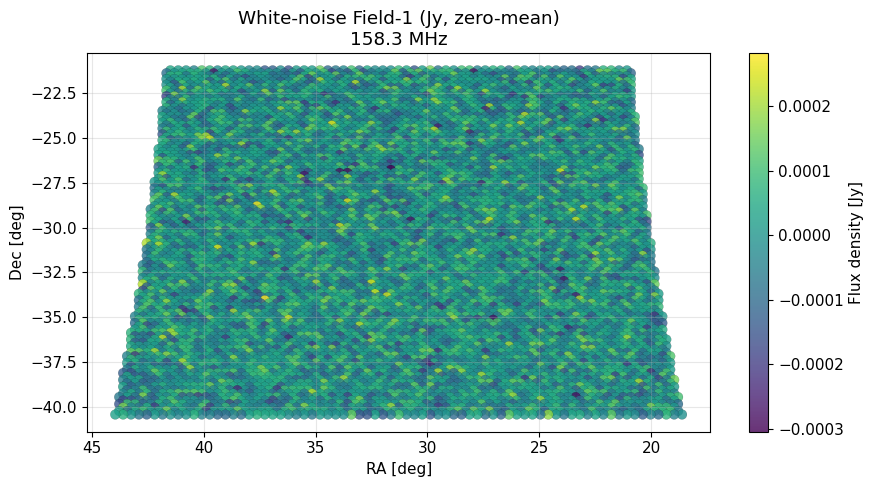

In [15]:
# ------------------------------------------------
# Field of view definition (matched to GSM)
# ------------------------------------------------
# Total angular width of the cropped region [deg]
FOV_DEG = 19.3621092978

# Copy full-sky RA/Dec coordinates from the sky model
ra_all  = sm_wn.ra.deg.copy()
dec_all = sm_wn.dec.deg.copy()

# ---------------------------
# Observation time
# ---------------------------
# Julian Date at which the zenith direction is evaluated
jd = 2458098.3065661727
t = Time(jd, format='jd')

# ---------------------------
# Zenith direction in AltAz
# ---------------------------
# Construct a local AltAz frame at the telescope location
altaz_frame = AltAz(obstime=t, location=telescope_location)

# Zenith corresponds to altitude = 90 deg
zenith_altaz = SkyCoord(
    alt=90 * u.deg,
    az=0 * u.deg,
    frame=altaz_frame
)

# Transform zenith direction to equatorial coordinates (ICRS)
zenith_radec = zenith_altaz.transform_to('icrs')

# Extract RA/Dec of the field centre
field_center_ra_deg  = zenith_radec.ra.deg
field_center_dec_deg = zenith_radec.dec.deg

print(
    f"Exact field center at JD={jd}: "
    f"RA={field_center_ra_deg:.3f} deg, "
    f"Dec={field_center_dec_deg:.3f} deg"
)

# ------------------------------------------------
# RA/Dec crop
# ------------------------------------------------
# RA condition:
# - RA offsets are scaled by cos(Dec) to represent true angular separation
# - This prevents artificial widening of the field at high declination
ra_mask = np.logical_and(
    (ra_all - field_center_ra_deg) * np.cos(np.deg2rad(dec_all)) >= -FOV_DEG / 2,
    (ra_all - field_center_ra_deg) * np.cos(np.deg2rad(dec_all)) <=  FOV_DEG / 2
)

# Dec condition:
# - Simple symmetric top-hat in declination
dec_mask = np.logical_and(
    dec_all >= field_center_dec_deg - FOV_DEG / 2,
    dec_all <= field_center_dec_deg + FOV_DEG / 2
)

# Combined trapezoidal mask in RA–Dec space
trap_mask = ra_mask & dec_mask

# ------------------------------------------------
# Apply crop to sky model
# ------------------------------------------------
# Select only components that fall inside the trapezoidal field
sm_wn_field1 = sm_wn.select(
    component_inds=np.where(trap_mask)[0],
    inplace=False
)

# ------------------------------------------------
# Extract cropped coordinates
# ------------------------------------------------
ra_f1_deg  = sm_wn_field1.ra.deg
dec_f1_deg = sm_wn_field1.dec.deg

# ------------------------------------------------
# HEALPix-related quantities
# ------------------------------------------------
nside = 256
npix = hp.nside2npix(nside)

# Solid angle per pixel [sr]
Omega_pix = 4 * np.pi / npix

# ------------------------------------------------
# Temperature to flux-density conversion
# ------------------------------------------------
# Extract Stokes I temperature [K]
temp_K = sm_wn_field1.stokes[0, 0].value

# Remove mean to isolate white-noise fluctuations
temp_K_zero_mean = temp_K - np.mean(temp_K)

# Frequency and wavelength
freq_hz = sm_wn_field1.freq_array[0].to("Hz").value
wavelength_m = c.value / freq_hz

# Rayleigh–Jeans conversion from temperature to flux density [Jy]
flux_Jy = (
    2 * k_B.value / wavelength_m**2
    * temp_K_zero_mean
    * Omega_pix
    * 1e26
)

# ------------------------------------------------
# Diagnostics
# ------------------------------------------------
print("White-noise statistics (Field-1, trapezoidal crop)")
print(f"  Components   : {sm_wn_field1.Ncomponents}")
print(f"  Std dev [Jy] : {np.std(flux_Jy):.3e}")
print(f"  Std dev [mK] : {np.std(temp_K_zero_mean) * 1e3:.3e}")

# ------------------------------------------------
# Visualisation
# ------------------------------------------------
plt.scatter(
    ra_f1_deg,
    dec_f1_deg,
    c=flux_Jy,
    s=50,
    cmap="viridis",
    edgecolors="k",
    linewidth=0.1,
    alpha=0.8
)

plt.colorbar(label="Flux density [Jy]")
plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.title(
    f"White-noise Field-1 (Jy, zero-mean)\n"
    f"{sm_wn_field1.freq_array[0].to('MHz').value:.1f} MHz"
)

# Astronomical convention: RA increases to the left
plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()


This cell loads a pre-generated white-noise sky for Field-1 and converts it to flux density.  
The result is compared to the cropped field by analysing and visualising the residual flux.

No frame available in this file, assuming 'icrs'. Consider re-writing this file to ensure future compatibility.
Some Stokes I values are negative. Use the select method with the 'non_negative' parameter to remove sources with negative Stokes I values.
It is more efficient to use the `get_lon_lat` method to get longitudinal and latitudinal coordinates for HEALPix maps.


Pre-generated Field-1 white-noise statistics
  Components   : 7152
  Std dev [Jy] : 8.097e-05
  Residual STD [Jy] : 1.344e-21


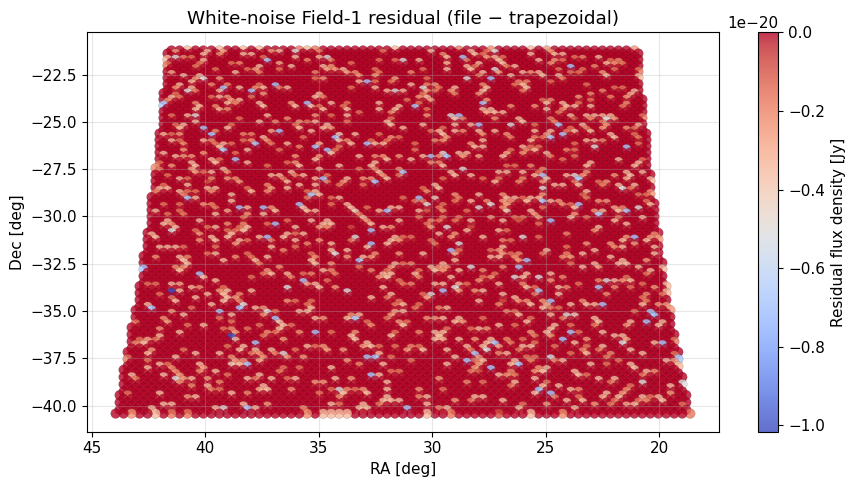

In [17]:
# ------------------------------------------------
# Load pre-generated Field-1 white-noise sky
# ------------------------------------------------
# Path to the skyH5 file containing the pre-generated Field-1 white-noise realisation
wn_file_f1 = os.path.join(
    catalog_root,
    "wn-nside256-rms-6.48mK-158.30-167.10MHz-nf-38-fov-19.4-field-1.skyh5"
)

# Read sky model from file
sm_wn_f1 = SkyModel()
sm_wn_f1.read_skyh5(wn_file_f1)

# ------------------------------------------------
# Extract coordinates and temperature
# ------------------------------------------------
ra_f1_file_deg  = sm_wn_f1.ra.deg
dec_f1_file_deg = sm_wn_f1.dec.deg

# Stokes I temperature [K]
temp_K_file = sm_wn_f1.stokes[0, 0].value

# ------------------------------------------------
# Temperature to flux-density conversion
# ------------------------------------------------
# Frequency and wavelength
freq_hz = sm_wn_f1.freq_array[0].to("Hz").value
wavelength_m = c.value / freq_hz

# Convert temperature fluctuations to flux density [Jy]
flux_Jy_file = (
    2 * k_B.value / wavelength_m**2
    * temp_K_file
    * Omega_pix
    * 1e26
)

# ------------------------------------------------
# Diagnostics
# ------------------------------------------------
print("Pre-generated Field-1 white-noise statistics")
print(f"  Components   : {sm_wn_f1.Ncomponents}")
print(f"  Std dev [Jy] : {np.std(flux_Jy_file):.3e}")

# ------------------------------------------------
# Residuals with respect to earlier crop
# ------------------------------------------------
# Difference between pre-generated field and trapezoidally cropped field
residual_flux_Jy = flux_Jy_file - flux_Jy

print(f"  Residual STD [Jy] : {np.std(residual_flux_Jy):.3e}")

# ------------------------------------------------
# Visualisation
# ------------------------------------------------
plt.scatter(
    ra_f1_file_deg,
    dec_f1_file_deg,
    c=residual_flux_Jy,
    s=50,
    cmap="coolwarm",
    edgecolors="k",
    linewidth=0.1,
    alpha=0.8
)

plt.colorbar(label="Residual flux density [Jy]")
plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.title("White-noise Field-1 residual")

# Astronomical convention: RA increases to the left
plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()

This cell then computes the RMS of the Stokes-I temperature fluctuations in Field-1 as a function of frequency and compares it to the expected white-noise level.

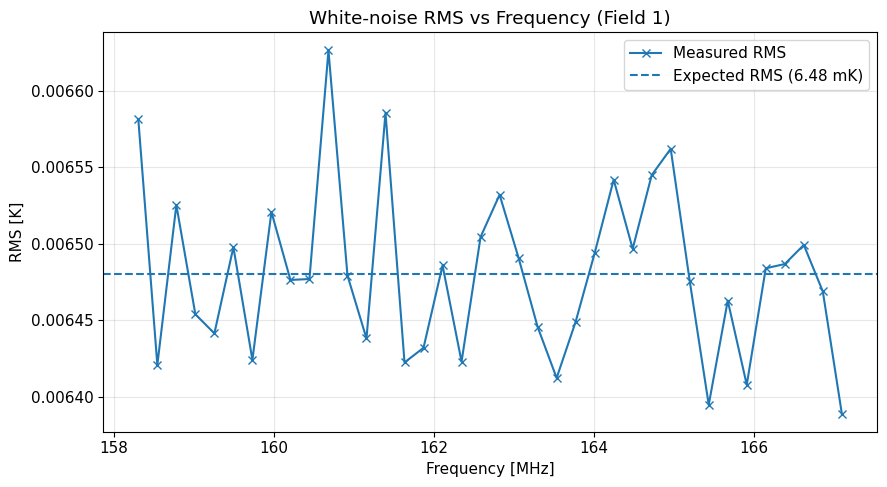

Mean RMS across band: 6.48 mK


In [19]:
# ------------------------------------------------------------
# RMS per frequency channel
# ------------------------------------------------------------
# Extract Stokes I temperature cube [K]
# Shape: (Nfreq, Ncomponents)
temp_K_f1 = sm_wn_field1.stokes[0].value

# Compute RMS across sky components for each frequency channel
rms_per_freq_K = temp_K_f1.std(axis=1)

# Frequency axis [MHz]
freqs_MHz = sm_wn_field1.freq_array.to("MHz").value

# ------------------------------------------------------------
# Plot RMS as a function of frequency
# ------------------------------------------------------------
plt.plot(freqs_MHz, rms_per_freq_K, "x-", label="Measured RMS")

# Expected white-noise RMS level
plt.axhline(
    6.48e-3,
    linestyle="--",
    label="Expected RMS (6.48 mK)"
)

plt.xlabel("Frequency [MHz]")
plt.ylabel("RMS [K]")
plt.title("White-noise RMS vs Frequency (Field 1)")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Band-averaged RMS
# ------------------------------------------------------------
print(f"Mean RMS across band: {rms_per_freq_K.mean() * 1e3:.2f} mK")

### 4.2 GLEAM Point-Source Catalogue

Extragalactic foregrounds are modelled using the GLEAM point-source catalogue. GLEAM provides source flux densities in a discrete set of frequency bands with non-uniform spacing, and does not resolve source spectra continuously across frequency.

To generate visibilities over the finely sampled simulation band, each source is assigned a power-law spectral model with a spectral index drawn from a Gaussian distribution (mean −2.82, standard deviation 0.19). Source flux densities are then interpolated to the simulation frequencies, introducing controlled spectral structure across the band.

This mock spectral modelling is not intended to reproduce detailed source spectra, but to ensure realistic chromaticity in the simulated sky, which is essential for assessing instrumental chromatic effects and foreground leakage.

Two versions of the sky catalogue are considered: a full-sky catalogue, and a restricted-FoV catalogue matched to the 19.4° image-domain sky model. This separation enables (in the future) explicit tests of the impact of unmodelled sky emission outside the modelled FoV.

N.B.: the FoV truncation has been perfomed in RA and DEC coordinates for GLEAM while it was done in Alt Az for GSM and WN.

Full-sky sources : 245469
Frequencies      : 38


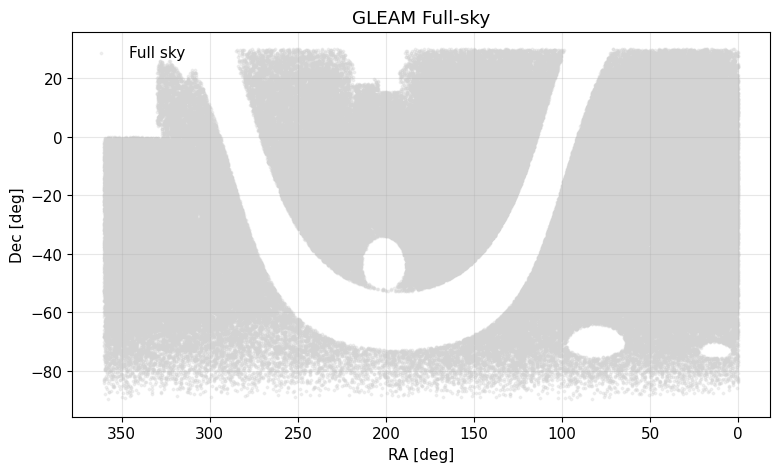

In [22]:
fullsky_file = os.path.join(
    catalog_root,
    "gleam-158.30-167.10-MHz-nf-38-pld-mean-2.82-std-0.19.skyh5"
)

sm_gleam_full   = SkyModel()
sm_gleam_full.read_skyh5(fullsky_file)

print(f"Full-sky sources : {sm_gleam_full.Ncomponents}")
print(f"Frequencies      : {sm_gleam_full.Nfreqs}")

plt.scatter(
    sm_gleam_full.ra.deg,
    sm_gleam_full.dec.deg,
    s=3,
    c="lightgray",
    alpha=0.3,
    label="Full sky"
)

plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.title("GLEAM Full-sky")
plt.gca().invert_xaxis()
plt.legend(frameon=False)
plt.show()

#### Rectangular RA–Dec crop of the GLEAM sky model

This cell extracts a rectangular Field-1 region from the full GLEAM sky model using simple RA and Dec bounds centred on the field centre.

RA center of cropped field:  31.300 deg
Dec center of cropped field: -30.800 deg


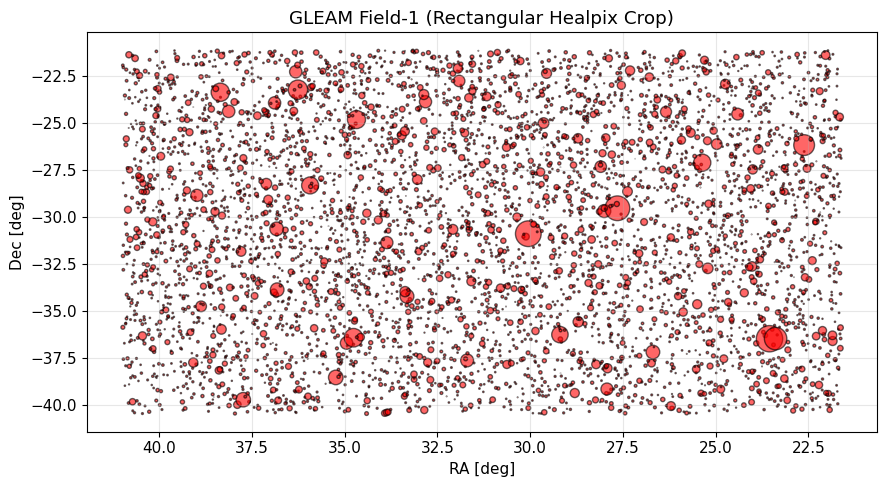

In [23]:
# ---------------------------
# Field-of-view bounds
# ---------------------------
# Define rectangular RA/Dec limits centred on the field centre
ra_min = field_center_ra_deg - FOV_DEG / 2
ra_max = field_center_ra_deg + FOV_DEG / 2

# Clamp declination to physical limits
dec_min = max(field_center_dec_deg - FOV_DEG / 2, -90)
dec_max = min(field_center_dec_deg + FOV_DEG / 2, 90)

# ---------------------------
# Crop GLEAM sky model
# ---------------------------
# Extract full-sky coordinates
ra_all  = sm_gleam_full.ra.deg
dec_all = sm_gleam_full.dec.deg

# Rectangular RA/Dec selection mask
ra_mask  = (ra_all  >= ra_min) & (ra_all  <= ra_max)
dec_mask = (dec_all >= dec_min) & (dec_all <= dec_max)
radec_mask = ra_mask & dec_mask

# Apply crop to the GLEAM sky model
sm_gleam_field1_model = sm_gleam_full.select(
    component_inds=np.where(radec_mask)[0],
    inplace=False
)

# ---------------------------
# Extract fluxes and coordinates
# ---------------------------
flux_Jy_field1_model = sm_gleam_field1_model.stokes[0, 0].value

ra_sel_deg  = sm_gleam_field1_model.ra.deg
dec_sel_deg = sm_gleam_field1_model.dec.deg

# Compute geometric centre of the cropped model (for diagnostics)
ra_center_model_deg  = 0.5 * (ra_sel_deg.max()  + ra_sel_deg.min())
dec_center_model_deg = 0.5 * (dec_sel_deg.max() + dec_sel_deg.min())

print(f"RA center of cropped field:  {ra_center_model_deg:.3f} deg")
print(f"Dec center of cropped field: {dec_center_model_deg:.3f} deg")

# ---------------------------
# Visualisation
# ---------------------------
plt.scatter(
    ra_sel_deg,
    dec_sel_deg,
    s=flux_Jy_field1_model * 20,
    c="red",
    alpha=0.6,
    edgecolors="k"
)

plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.title("GLEAM Field-1 (Rectangular Healpix Crop)")

# Astronomical convention: RA increases to the left
plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()

This nextcell loads the pre-generated GLEAM Field-1 sky and computes Stokes-I residuals with respect to the rectangularly cropped GLEAM model.

In [26]:
# ------------------------------------------------
# Load pre-generated GLEAM Field-1 sky
# ------------------------------------------------
field1_file = os.path.join(
    catalog_root,
    "gleam-field-1-158.30-167.10-MHz-nf-38-fov-19.4-pld-mean-2.82-std-0.19.skyh5"
)

# Read Field-1 sky model from file
sm_gleam_field1 = SkyModel()
sm_gleam_field1.read_skyh5(field1_file)

# ------------------------------------------------
# Residuals: data − model
# ------------------------------------------------
# Stokes I flux density from pre-generated Field-1 sky [Jy]
flux_Jy_data = sm_gleam_field1.stokes[0, 0].value

# Stokes I flux density from rectangularly cropped GLEAM model [Jy]
flux_Jy_model = sm_gleam_field1_model.stokes[0, 0].value

# Sanity check: both skies must contain the same sources
print(f"Number of sources (data):  {flux_Jy_data.size}")
print(f"Number of sources (model): {flux_Jy_model.size}")
assert flux_Jy_data.size == flux_Jy_model.size

# Compute residual Stokes I flux density
residual_flux_Jy = flux_Jy_data - flux_Jy_model

# ------------------------------------------------
# Residual statistics
# ------------------------------------------------
print(f"Residual Stokes I mean: {residual_flux_Jy.mean():.4e} Jy")
print(f"Residual Stokes I std : {residual_flux_Jy.std():.4e} Jy")


Number of sources (data):  4996
Number of sources (model): 4996
Residual Stokes I mean: 0.0000e+00 Jy
Residual Stokes I std : 0.0000e+00 Jy


#### Spectral index distribution of GLEAM Field-1 sources

This cell estimates flux-density spectral indices across the GLEAM band using the lowest and highest frequency channels and visualises their distribution.

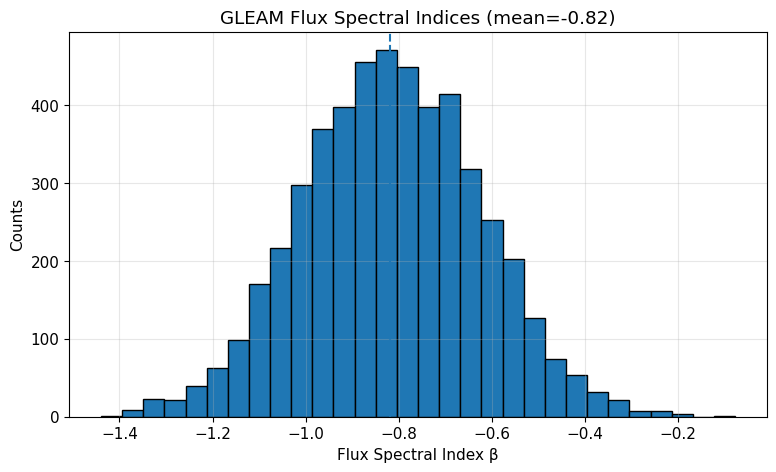

In [138]:
freqs_gleam_MHz = sm_gleam_field1.freq_array.to("MHz").value
S_low  = sm_gleam_field1.stokes[0, 0].value
S_high = sm_gleam_field1.stokes[0, -1].value

spectral_index_beta = -np.log(S_low / S_high) / np.log(
    freqs_gleam_MHz[-1] / freqs_gleam_MHz[0]
)

plt.hist(spectral_index_beta, bins=30, edgecolor="k")
plt.axvline(-0.82, linestyle="--")
plt.xlabel("Flux Spectral Index β")
plt.ylabel("Counts")
plt.title(
    f"GLEAM Flux Spectral Indices "
    f"(mean={spectral_index_beta.mean():.2f})"
)
plt.show()

## 4.3 Global Sky Model (Diffuse Foregrounds)

Diffuse Galactic and extragalactic foreground emission is modelled using the Global Sky Model (GSM), generated on a HEALPix grid with nside = 256 at the simulation frequencies.

As with the point-source component, both full-sky and restricted-FoV GSM realisations are used to assess the validity of restricted image-domain modelling.

No frame available in this file, assuming 'icrs'. Consider re-writing this file to ensure future compatibility.
Some Stokes I values are negative. Use the select method with the 'non_negative' parameter to remove sources with negative Stokes I values.
It is more efficient to use the `get_lon_lat` method to get longitudinal and latitudinal coordinates for HEALPix maps.


GSM Components: 786432
Frequencies:    38


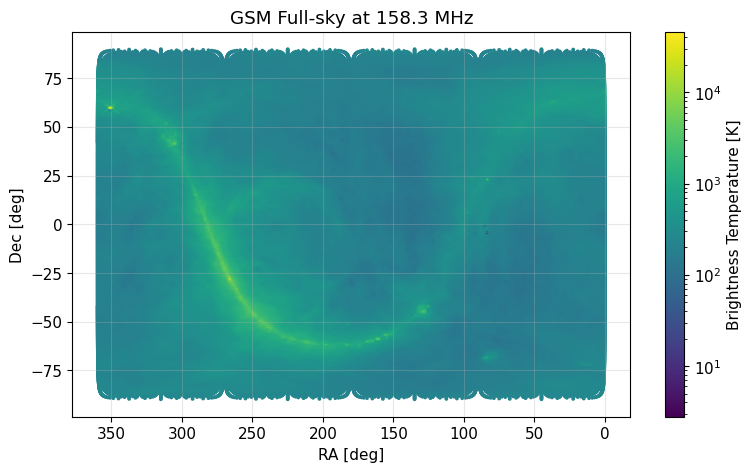

In [27]:
fullsky_gsm_file = os.path.join(
    catalog_root,
    "gsm-nside256-158.3-167.1MHz-nf-38.skyh5"
)

sm_gsm = SkyModel()
sm_gsm.read_skyh5(fullsky_gsm_file)

print(f"GSM Components: {sm_gsm.Ncomponents}")
print(f"Frequencies:    {sm_gsm.Nfreqs}")

ra_gsm_deg  = sm_gsm.ra.deg
dec_gsm_deg = sm_gsm.dec.deg
temp_K_gsm  = sm_gsm.stokes[0, 0].to("K").value

plt.scatter(
    ra_gsm_deg,
    dec_gsm_deg,
    c=temp_K_gsm,
    s=3,
    cmap="viridis",
    norm=LogNorm()
)

plt.colorbar(label="Brightness Temperature [K]")
plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.title(
    f"GSM Full-sky at "
    f"{sm_gsm.freq_array[0].to('MHz').value:.1f} MHz"
)
plt.gca().invert_xaxis()
plt.show()

#### Crop of the GSM sky model (Field-1)

This cell applies the same trapezoidal RA–Dec field-of-view mask used previously to the GSM sky model and converts the resulting temperature map to flux density.

It is more efficient to use the `get_lon_lat` method to get longitudinal and latitudinal coordinates for HEALPix maps.


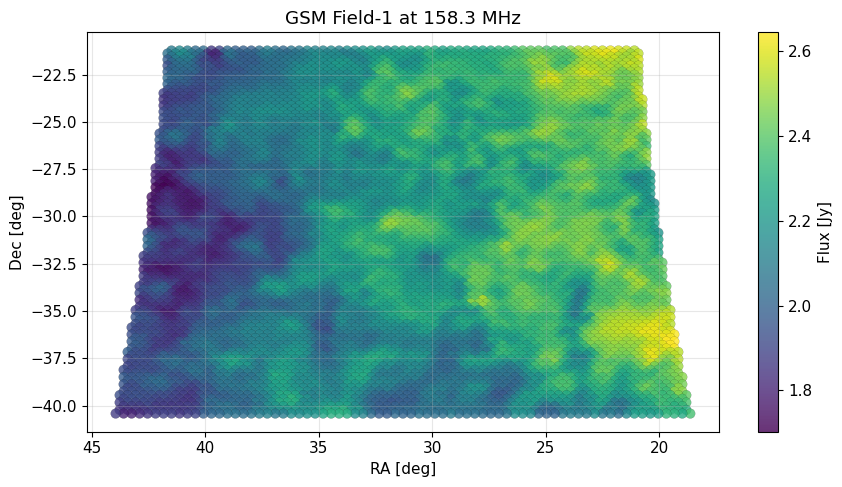

In [28]:
# ------------------------------------------------
# RA–Dec crop (GSM)
# ------------------------------------------------
# RA selection with cos(Dec) scaling to represent true angular separation
ra_mask = np.logical_and(
    (ra_gsm_deg - field_center_ra_deg) * np.cos(np.deg2rad(dec_gsm_deg))
    >= -FOV_DEG / 2,
    (ra_gsm_deg - field_center_ra_deg) * np.cos(np.deg2rad(dec_gsm_deg))
    <=  FOV_DEG / 2
)

# Declination selection (symmetric top-hat)
dec_mask = np.logical_and(
    dec_gsm_deg >= field_center_dec_deg - FOV_DEG / 2,
    dec_gsm_deg <= field_center_dec_deg + FOV_DEG / 2
)

# Combined mask
trap_mask = ra_mask & dec_mask

# Apply crop to the GSM sky model
sm_gsm_field1_model = sm_gsm.select(
    component_inds=np.where(trap_mask)[0],
    inplace=False
)

# ------------------------------------------------
# Extract coordinates and temperature
# ------------------------------------------------
ra_f1_deg  = sm_gsm_field1_model.ra.deg
dec_f1_deg = sm_gsm_field1_model.dec.deg

# Stokes I temperature [K]
temp_K_f1 = sm_gsm_field1_model.stokes[0, 0].value

# ------------------------------------------------
# Temperature to flux-density conversion
# ------------------------------------------------
freq_hz = sm_gsm_field1_model.freq_array[0].to("Hz").value
wavelength_m = c.value / freq_hz

flux_Jy_f1 = (
    2 * k_B.value / wavelength_m**2
    * temp_K_f1
    * Omega_pix
    * 1e26
)

# ------------------------------------------------
# Visualisation
# ------------------------------------------------
plt.scatter(
    ra_f1_deg,
    dec_f1_deg,
    c=flux_Jy_f1,
    s=50,
    cmap="viridis",
    edgecolors="k",
    linewidth=0.1,
    alpha=0.8
)

plt.colorbar(label="Flux [Jy]")
plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.title(
    f"GSM Field-1 "
    f"at {sm_gsm_field1_model.freq_array[0].to('MHz').value:.1f} MHz"
)

# Astronomical convention: RA increases to the left
plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()

This cell loads a pre-generated GSM Field-1 sky and computes pixel-wise Stokes-I residuals with respect to the cropped GSM reference field.

In [41]:
# ------------------------------------------------
# Load pre-generated GSM Field-1 sky
# ------------------------------------------------
gsm_field1_file = os.path.join(
    catalog_root,
    "gsm-nside256-158.3-167.1MHz-nf-38-fov-19.4-field-1.skyh5"
)

sm_gsm_field1 = SkyModel()
sm_gsm_field1.read_skyh5(gsm_field1_file)

# ------------------------------------------------
# Residuals: GSM field file − reference GSM crop
# ------------------------------------------------
temp_K_data = sm_gsm_field1.stokes[0, 0].value

I_jy_data = (
    2 * k_B.value / wavelength_m**2
    * temp_K_data
    * Omega_pix
    * 1e26
)

# Model flux already computed in the previous cell
I_jy_model = flux_Jy_f1

# Pixel-wise residual
residual_I_jy = I_jy_data - I_jy_model

# ------------------------------------------------
# Residual statistics
# ------------------------------------------------
res_mean = np.mean(residual_I_jy)
res_std  = np.std(residual_I_jy)

print(f"Residual mean: {res_mean:.4e} Jy")
print(f"Residual std : {res_std:.4e} Jy")

Residual mean: 0.0000e+00 Jy
Residual std : 0.0000e+00 Jy


No frame available in this file, assuming 'icrs'. Consider re-writing this file to ensure future compatibility.


Diffuse Galactic foreground emission in the Global Sky Model (GSM) is expected to vary smoothly with frequency and to follow,

$$
T(\nu) \propto \nu^{-2.62},
$$

consistent with synchrotron-dominated emission in the low-frequency radio regime. 


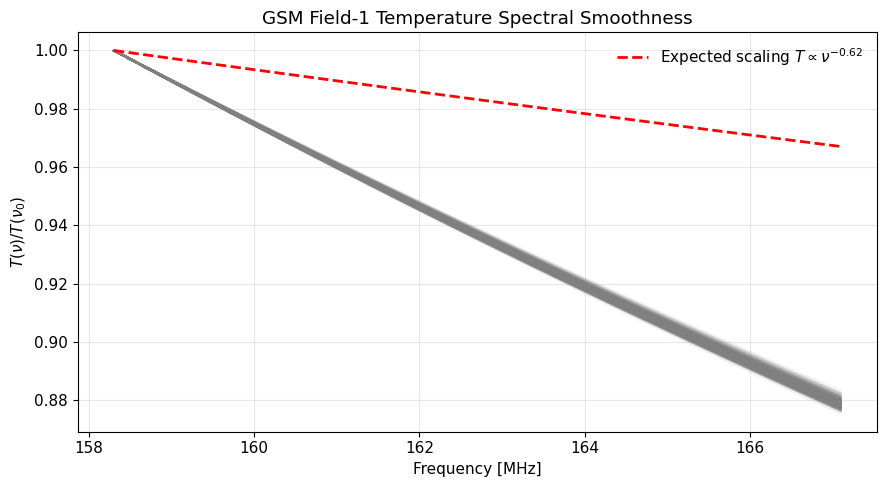

In [42]:
# ------------------------------------------------------------
# GSM Field-1 spectral smoothness (temperature)
# ------------------------------------------------------------
# Inspect spectral smoothness by plotting normalised pixel spectra

np.random.seed(42)

# Random subset of GSM pixels
num_pixels  = sm_gsm_field1.Ncomponents
pixel_sample = np.random.randint(0, num_pixels, 300)

# Frequency axis
freqs_gsm_MHz = sm_gsm_field1.freq_array.to("MHz").value

# Plot normalised temperature spectra
for idx in pixel_sample:
    spec = sm_gsm_field1.stokes[0, :, idx].value
    plt.plot(freqs_gsm_MHz, spec / spec[0], color="gray", alpha=0.1)

# Reference power-law scaling
plt.plot(
    freqs_gsm_MHz,
    (freqs_gsm_MHz / freqs_gsm_MHz[0])**(-0.62),
    "r--",
    linewidth=2,
    label=r"Expected scaling $T \propto \nu^{-0.62}$"
)

plt.xlabel("Frequency [MHz]")
plt.ylabel(r"$T(\nu) / T(\nu_0)$")
plt.title("GSM Field-1 Temperature Spectral Smoothness")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

We next examine the distribution of spectral indices across the GSM Field-1 pixels.

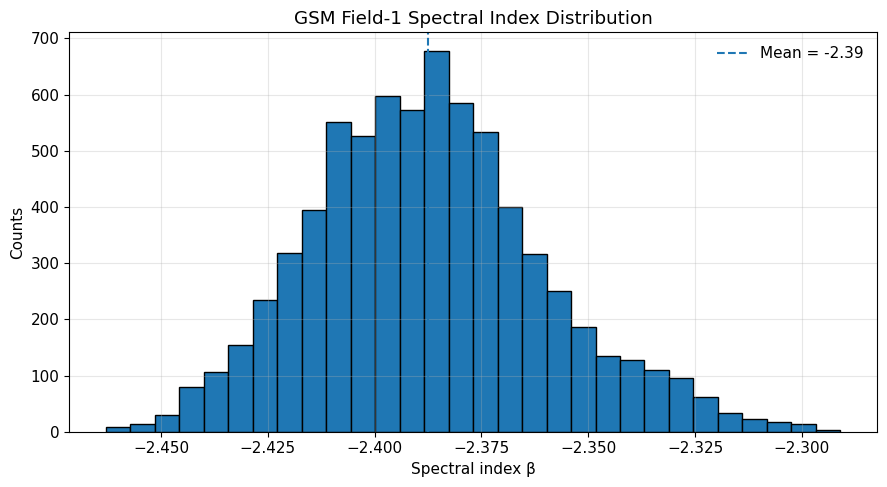

In [43]:
# ------------------------------------------------------------
# GSM spectral index distribution
# ------------------------------------------------------------
# Compute per-pixel spectral index between lowest and highest frequencies

T_low  = sm_gsm_field1.stokes[0, 0].value
T_high = sm_gsm_field1.stokes[0, -1].value

# Valid pixels (avoid log of non-positive values)
mask = (T_low > 0) & (T_high > 0)

beta_gsm = np.full_like(T_low, np.nan, dtype=float)
beta_gsm[mask] = (
    np.log(T_high[mask]) - np.log(T_low[mask])
) / np.log(freqs_gsm_MHz[-1] / freqs_gsm_MHz[0])

# Histogram
plt.hist(beta_gsm[np.isfinite(beta_gsm)], bins=30, edgecolor="k")

mean_beta = np.nanmean(beta_gsm)
plt.axvline(mean_beta, linestyle="--", label=f"Mean = {mean_beta:.2f}")

plt.xlabel("Spectral index β")
plt.ylabel("Counts")
plt.title("GSM Field-1 Spectral Index Distribution")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()